pystran - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss sizing optimization:  Groups of bars.

Last updated: 06/27/26

## Description

Optimize the cross sectional areas of a truss structure to achieve its 
minimum weight. The bars are grouped into four groups: bottom chord, top chord, verticals, and diagonals.
Each of the four groups can have a different cross sectional area.

Objective function: mass of the structure. The design variables are the relative cross sectional areas of the four groups of bars.

Constraints: (1) limit on maximum deflection, and (2) the design variables (i.e. the cross sectional areas) are bounded from below (so that they are greater than zero).

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraint
$$
    c_j(x) \ge 0 \; , j=1,2
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.



First we bring in the modules and functions that we will need.

In [43]:
import context
from numpy import max, ones
from pystran import model
from pystran import section
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. Next, we define some useful constants.

Initially, all members in all groups have cross sections of these dimensions (in millimeters square).

In [44]:
INITIAL_AREA = 150.0

The minimum area of any group of bars is 1/100 of the initial area. Therefore, the smallest admissible value of a design variable is 0.01.  This constraint will be enforced by the "lower bound" constraint defined below.

In [45]:
MINIMUM_DV = 0.01

No joint is allowed to move than this maximum allowed deflection (in millimeters):


In [46]:
MAXIMUM_ALLOWED_DEFLECTION = 20.0


The material properties correspond roughly to steel.


In [47]:
E = 200000
RHO = 7.8e-9


The magnitude of the vertical (downward) forces in Newton.


In [48]:
W = 6000

The following lists define the bars for all four groups: 

In [49]:
BOTTOM_CHORD_BAR_CONNECTIVITIES = [
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ]
TOP_CHORD_BAR_CONNECTIVITIES = [
    [6, 7],
    [7, 8],
    [8, 9],
    [9, 10],
]
VERTICAL_BAR_CONNECTIVITIES = [
    [1, 6],
    [2, 7],
    [3, 8],
    [4, 9],
    [5, 10],
]
DIAGONAL_BAR_CONNECTIVITIES = [
    [1, 7],
    [3, 9],
    [3, 7],
    [5, 9],
]

The design variables are nondimensional multipliers of the initial cross sectional area of each group.
The cross sectional area of each group of bars is `dvs[i] * INITIAL_AREA`. The design variables start 
at the value of 1.0.

In [50]:
dvs0 = ones(4)

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. 


In [51]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-6000, 0])
    model.add_joint(m, 7, [-3000, 0])
    model.add_joint(m, 8, [0, 0])
    model.add_joint(m, 9, [3000, 0])
    model.add_joint(m, 10, [6000, 0])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    # We start with the bottom chord bars.
    s = section.truss_section(f"s_bottom_chord", E=E, A=INITIAL_AREA * dvs[0], rho=RHO)
    for k, c in enumerate(BOTTOM_CHORD_BAR_CONNECTIVITIES):
        model.add_truss_member(m, f"bottom_chord_{k}", c, s)
    # Next we have the top chord.
    s = section.truss_section(f"s_top_chord", E=E, A=INITIAL_AREA * dvs[1], rho=RHO)
    for k, c in enumerate(TOP_CHORD_BAR_CONNECTIVITIES):
        model.add_truss_member(m, f"top_chord_{k}", c, s)
    # Next the verticals.
    s = section.truss_section(f"s_vertical", E=E, A=INITIAL_AREA * dvs[2], rho=RHO)
    for k, c in enumerate(VERTICAL_BAR_CONNECTIVITIES):
        model.add_truss_member(m, f"vertical_{k}", c, s)
    # Finally the diagonals.
    s = section.truss_section(f"s_diagonal", E=E, A=INITIAL_AREA * dvs[3], rho=RHO)
    for k, c in enumerate(DIAGONAL_BAR_CONNECTIVITIES):
        model.add_truss_member(m, f"diagonal_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


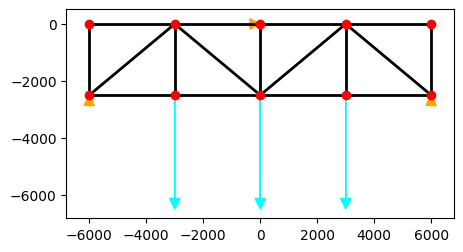

In [52]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [53]:
mass = RHO * model.volume(m)
print('Initial mass = ', mass, ' [metric tones]')

Initial mass =  0.06098098424162156  [metric tones]


This helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. The design 
responses are the mass of the structure and  
the maximum displacement magnitude. They are returned as a tuple.


In [54]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    drs = (
        RHO * model.volume(m),
        max(abs(m["U"])),
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [55]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", initial_mass, ' [metric tones]')
print("Initial largest deflection: ", initial_max_deflection, '[mm]')



Initial structure
-----------------
Initial Design Variables:  [1. 1. 1. 1.]
Mass:  0.06098098424162156  [metric tones]
Initial largest deflection:  9.859401841842457 [mm]


Note that as designed, the structure has a smaller deflection than allowed. Therefore we may expect the mass of the structure to go down.

At this point we start on the optimization. The objective 
function and the constraints need to be defined. 

In [56]:
# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

Define a constraint on the maximum deflection.  The constraint here is on the maximum deflection, $(u_{max}-\max u)/u_{max}\ge 0$: Here $u_{max}$=`MAXIMUM_ALLOWED_DEFLECTION`.

In [57]:
def constrain_deflection(dvs):
    drs = solve(dvs)
    max_deflection = drs[1]
    return (MAXIMUM_ALLOWED_DEFLECTION - max_deflection) / MAXIMUM_ALLOWED_DEFLECTION

cons = [
    {"type": "ineq", "fun": constrain_deflection},
]

The function `constrain_deflection` is used to define an inequality constraint. All such constraints are collected in the list `cons`.




Define lower bounds for the design variables. There are no upper bounds (the `None`).


In [58]:
bounds = [(MINIMUM_DV, None) for _ in dvs0]

Invoke the optimization function. 


In [59]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.39637214432396595
            Iterations: 39
            Function evaluations: 318
            Gradient evaluations: 39


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [60]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The largest deflection is equal to the maximum allowed, and that constraint is then the only active constraint.

In [61]:
mass = drs[0]
max_deflection = drs[1]
print("\nOptimized structure")
print("-----------------")
print("Solution success: ", solution.success, f" ({solution.nit} iterations)")
print("Design Variables: ", dvs)
print("Mass: ", mass, ' [metric tones]')
print("Largest deflection: ", max_deflection, '[mm]')


Optimized structure
-----------------
Solution success:  True  (39 iterations)
Design Variables:  [0.46965316 0.51025908 0.09409962 0.49447343]
Mass:  0.024171163486837514  [metric tones]
Largest deflection:  20.00000000000292 [mm]


Print out the cross sectional areas of the four groups (in millimeters square).


In [62]:
print("Areas of groups of bars: ")
m = truss_model(dvs)
for (j, v) in enumerate(dvs):
    print(f"Group {j}: {INITIAL_AREA * v}")

Areas of groups of bars: 
Group 0: 70.44797389957283
Group 1: 76.53886265174572
Group 2: 14.114942995037367
Group 3: 74.17101473832419


The following visualization provides a graphical assessment of the optimized structure: bars with large cross sectional area are shown with thick lines, and conversely bars whose cross sectional area is small are very thin.

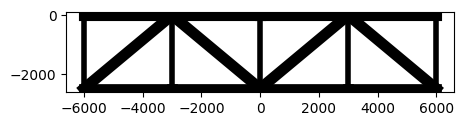

In [63]:
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m)

Notice the corners: there are no more null bars.


## Conclusions

Optimizing the cross sectional areas of groups of bars facilitates construction: for instance the chords can be made continuous, from a single profile.